# Whisper WAV + 타임스탬프 라벨 전처리

이 노트북은 다음 형식의 라벨과 WAV 파일을 받아 Whisper fine-tuning용 데이터를 만듭니다.

```text
[2.270,3.400]\tG0102\tmale\t매직 데이터
```

핵심 동작:

1. FFmpeg로 WAV를 16 kHz mono PCM으로 디코딩합니다.
2. 발화를 중간에서 자르지 않고 최대 30초 단위로 묶습니다.
3. 각 오디오 조각을 30초로 zero-padding합니다.
4. 첨부한 Whisper 코드와 같은 방식으로 Log-Mel spectrogram을 계산합니다.
5. `(n_mels, 3000)` NumPy 특징 파일과 `manifest.jsonl`을 저장합니다.
6. 원하면 OpenAI Whisper tokenizer로 label token ID도 생성합니다.

> 고정된 `[0, 30)`, `[30, 60)` 구간으로 자르지 않습니다. 30초 경계를 넘는 발화가 잘리는 것을 방지하기 위해 라벨의 발화 경계를 사용합니다.


## 0. 준비 사항

필수 항목:

- Python 3.9 이상
- FFmpeg가 PATH에 등록되어 있어야 함
- `numpy`, `torch`, `librosa`, `matplotlib`
- token ID도 만들려면 `openai-whisper`

필요한 경우 아래 설치 셀의 주석을 해제해서 실행하세요.


In [ ]:
##%pip install librosa matplotlib openai-whisper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 KB 9.1 MB/s eta 0:00:00
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
  Using cached openai_whisper-20250625-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 10.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/245.0 KB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 KB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.6/407.6 KB 10.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 11.1 MB/s eta 0:00:00a 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached font

In [9]:
import json
import os
import re
import wave
from dataclasses import asdict, dataclass
from functools import lru_cache
from pathlib import Path
from subprocess import CalledProcessError, run
from typing import List, Optional, Sequence, Tuple, Union

import numpy as np
import torch
import torch.nn.functional as F

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


PyTorch: 2.12.1+cu130
CUDA available: True


## 1. 설정

`DATA_PAIRS`에 WAV와 라벨 파일을 한 쌍 이상 등록하세요. Windows에서도 `/` 경로 구분자를 사용할 수 있습니다.


In [10]:
# 예시 경로를 실제 파일 경로로 변경하세요.
DATA_PAIRS: List[Tuple[Path, Path]] = [
    (Path(r'/home/lmh/project/whisper/Summer_Bootcamp/data/wav/A0051_S0001_0_G0101.wav'), Path(r'/home/lmh/project/whisper/Summer_Bootcamp/data/text/A0051_S0001_0_G0101.txt')),
]

OUTPUT_DIR = Path('./whisper_preprocessed')

# Whisper 오디오 설정
SAMPLE_RATE = 16_000
N_FFT = 400
HOP_LENGTH = 160
CHUNK_LENGTH = 30
N_SAMPLES = CHUNK_LENGTH * SAMPLE_RATE       # 480000
N_FRAMES = N_SAMPLES // HOP_LENGTH           # 3000

# checkpoint와 반드시 일치시켜야 합니다.
# 기존 Whisper 계열은 보통 80, large-v3/turbo 계열은 128입니다.
N_MELS = 80
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# chunk 설정
GROUP_MODE = 'pack'        # 'pack': 최대 30초로 묶기, 'single': 발화 한 줄당 하나
PRE_ROLL_SECONDS = 0.20    # 첫 발화 앞에 추가할 오디오
POST_ROLL_SECONDS = 0.20   # 마지막 발화 뒤에 추가할 오디오
MAX_GAP_SECONDS = None     # 예: 5.0이면 5초보다 긴 침묵에서 새 chunk 시작
LABEL_ENCODING = 'utf-8-sig'
LABEL_TIME_TOLERANCE = 0.10

# 출력 설정
SAVE_AUDIO_CHUNKS = True   # crop된 원래 길이의 PCM16 WAV도 저장

# 텍스트 label token ID 생성 옵션
TOKENIZE_LABELS = False    # True이면 openai-whisper 패키지 필요
LANGUAGE = 'ko'
TASK = 'transcribe'        # 'transcribe' 또는 'translate'
INCLUDE_TIMESTAMP_TOKENS = False
MAX_DECODER_TOKENS = 448

# OpenAI Whisper 패키지의 mel_filters.npz를 직접 지정할 수도 있습니다.
# None이면 설치된 whisper 패키지에서 찾고, 없으면 librosa로 동일한 필터를 생성합니다.
MEL_FILTERS_NPZ: Optional[Path] = None


## 2. 첨부 코드 기반 오디오 함수


In [11]:
def load_audio(file: Union[str, Path], sr: int = SAMPLE_RATE) -> np.ndarray:
    """FFmpeg로 오디오를 mono, 16 kHz, float32 [-1, 1) 파형으로 읽습니다."""
    cmd = [
        'ffmpeg',
        '-nostdin',
        '-threads', '0',
        '-i', str(file),
        '-f', 's16le',
        '-ac', '1',
        '-acodec', 'pcm_s16le',
        '-ar', str(sr),
        '-',
    ]
    try:
        out = run(cmd, capture_output=True, check=True).stdout
    except FileNotFoundError as exc:
        raise RuntimeError('FFmpeg를 찾을 수 없습니다. FFmpeg를 설치하고 PATH를 확인하세요.') from exc
    except CalledProcessError as exc:
        raise RuntimeError(f'오디오 로딩 실패: {exc.stderr.decode(errors="replace")}') from exc

    return np.frombuffer(out, dtype='<i2').flatten().astype(np.float32) / 32768.0


def pad_or_trim(array, length: int = N_SAMPLES, *, axis: int = -1):
    """지정 축을 length 길이로 자르거나 오른쪽을 0으로 padding합니다."""
    if torch.is_tensor(array):
        if array.shape[axis] > length:
            index = torch.arange(length, device=array.device)
            array = array.index_select(dim=axis, index=index)

        if array.shape[axis] < length:
            pad_widths = [(0, 0)] * array.ndim
            pad_widths[axis] = (0, length - array.shape[axis])
            array = F.pad(array, [p for sizes in pad_widths[::-1] for p in sizes])
    else:
        if array.shape[axis] > length:
            array = array.take(indices=range(length), axis=axis)

        if array.shape[axis] < length:
            pad_widths = [(0, 0)] * array.ndim
            pad_widths[axis] = (0, length - array.shape[axis])
            array = np.pad(array, pad_widths)

    return array


def _find_whisper_filter_asset() -> Optional[Path]:
    if MEL_FILTERS_NPZ is not None:
        path = Path(MEL_FILTERS_NPZ)
        if not path.exists():
            raise FileNotFoundError(f'MEL_FILTERS_NPZ가 존재하지 않습니다: {path}')
        return path

    try:
        import whisper
        path = Path(whisper.__file__).resolve().parent / 'assets' / 'mel_filters.npz'
        return path if path.exists() else None
    except ImportError:
        return None


@lru_cache(maxsize=None)
def mel_filters(device: str, n_mels: int) -> torch.Tensor:
    """Whisper와 같은 고정 Mel filter-bank 행렬을 반환합니다."""
    if n_mels not in {80, 128}:
        raise ValueError(f'n_mels는 80 또는 128이어야 합니다: {n_mels}')

    asset_path = _find_whisper_filter_asset()
    if asset_path is not None:
        with np.load(asset_path, allow_pickle=False) as data:
            filters_np = data[f'mel_{n_mels}'].astype(np.float32, copy=False)
    else:
        try:
            import librosa
        except ImportError as exc:
            raise RuntimeError(
                'mel_filters.npz를 찾지 못했고 librosa도 없습니다. '
                'openai-whisper 또는 librosa를 설치하세요.'
            ) from exc
        filters_np = librosa.filters.mel(
            sr=SAMPLE_RATE, n_fft=N_FFT, n_mels=n_mels
        ).astype(np.float32)

    expected_shape = (n_mels, N_FFT // 2 + 1)
    if filters_np.shape != expected_shape:
        raise ValueError(f'Mel filter shape 오류: {filters_np.shape}, expected={expected_shape}')

    return torch.from_numpy(filters_np).to(device)


def log_mel_spectrogram(
    audio: Union[str, Path, np.ndarray, torch.Tensor],
    n_mels: int = N_MELS,
    padding: int = 0,
    device: Optional[Union[str, torch.device]] = None,
) -> torch.Tensor:
    """첨부한 Whisper 코드와 같은 Log-Mel spectrogram을 계산합니다."""
    if not torch.is_tensor(audio):
        if isinstance(audio, (str, Path)):
            audio = load_audio(audio)
        audio = torch.from_numpy(np.asarray(audio, dtype=np.float32))

    if device is not None:
        audio = audio.to(device)
    if padding > 0:
        audio = F.pad(audio, (0, padding))

    window = torch.hann_window(N_FFT, device=audio.device)
    stft = torch.stft(
        audio, N_FFT, HOP_LENGTH, window=window, return_complex=True
    )
    magnitudes = stft[..., :-1].abs() ** 2

    filters = mel_filters(str(audio.device), n_mels)
    mel_spec = filters @ magnitudes

    log_spec = torch.clamp(mel_spec, min=1e-10).log10()
    log_spec = torch.maximum(log_spec, log_spec.max() - 8.0)
    log_spec = (log_spec + 4.0) / 4.0
    return log_spec


## 3. 라벨 파싱과 30초 이하 chunk 생성

라벨의 절대 타임스탬프는 manifest에 보존하고, chunk 내부 상대 타임스탬프도 함께 계산합니다.


In [12]:
TIME_PATTERN = re.compile(
    r'^\[\s*(?P<start>\d+(?:\.\d+)?)\s*,\s*(?P<end>\d+(?:\.\d+)?)\s*\]$'
)


@dataclass(frozen=True)
class Segment:
    start: float
    end: float
    speaker: str
    gender: str
    text: str


@dataclass(frozen=True)
class Chunk:
    crop_start: float
    crop_end: float
    segments: Tuple[Segment, ...]

    @property
    def duration(self) -> float:
        return self.crop_end - self.crop_start

    @property
    def text(self) -> str:
        return ' '.join(segment.text.strip() for segment in self.segments).strip()


def read_label_file(path: Union[str, Path]) -> List[Segment]:
    path = Path(path)
    segments: List[Segment] = []

    with path.open('r', encoding=LABEL_ENCODING) as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.rstrip('\r\n')
            if not line.strip():
                continue

            fields = line.split('\t', 3)
            if len(fields) != 4:
                raise ValueError(
                    f'{path}:{line_number}: 탭으로 구분된 4개 필드가 필요합니다: {line!r}'
                )

            time_field, speaker, gender, text = fields
            match = TIME_PATTERN.fullmatch(time_field.strip())
            if match is None:
                raise ValueError(
                    f'{path}:{line_number}: 잘못된 시간 형식입니다: {time_field!r}'
                )

            start = float(match.group('start'))
            end = float(match.group('end'))
            if start < 0 or end <= start:
                raise ValueError(
                    f'{path}:{line_number}: start/end가 잘못되었습니다: {start}, {end}'
                )
            if not text.strip():
                raise ValueError(f'{path}:{line_number}: transcript가 비어 있습니다.')

            segments.append(
                Segment(start, end, speaker.strip(), gender.strip(), text.strip())
            )

    segments.sort(key=lambda segment: (segment.start, segment.end))
    if not segments:
        raise ValueError(f'유효한 라벨이 없습니다: {path}')
    return segments


def _make_chunk(group: Sequence[Segment], audio_duration: float) -> Chunk:
    speech_start = group[0].start
    speech_end = group[-1].end
    crop_start = max(0.0, speech_start - PRE_ROLL_SECONDS)
    crop_end = min(audio_duration, speech_end + POST_ROLL_SECONDS)

    if crop_end - crop_start > CHUNK_LENGTH + 1e-9:
        raise ValueError(
            f'chunk가 30초를 넘습니다: {crop_start:.3f}~{crop_end:.3f}. '
            'PRE/POST_ROLL을 줄이거나 라벨을 더 세밀하게 분할하세요.'
        )
    return Chunk(crop_start, crop_end, tuple(group))


def make_chunks(segments: Sequence[Segment], audio_duration: float) -> List[Chunk]:
    for segment in segments:
        if segment.end > audio_duration + LABEL_TIME_TOLERANCE:
            raise ValueError(
                f'라벨 종료 시각 {segment.end:.3f}s가 오디오 길이 '
                f'{audio_duration:.3f}s를 넘습니다: {segment.text}'
            )
        if segment.end - segment.start > CHUNK_LENGTH:
            raise ValueError(
                f'단일 발화가 30초를 넘습니다. 더 작은 라벨이 필요합니다: {segment}'
            )

    if GROUP_MODE == 'single':
        return [_make_chunk([segment], audio_duration) for segment in segments]
    if GROUP_MODE != 'pack':
        raise ValueError(f'지원하지 않는 GROUP_MODE: {GROUP_MODE!r}')

    chunks: List[Chunk] = []
    current: List[Segment] = []

    for segment in segments:
        if not current:
            current = [segment]
            continue

        candidate_start = max(0.0, current[0].start - PRE_ROLL_SECONDS)
        candidate_end = min(audio_duration, segment.end + POST_ROLL_SECONDS)
        duration_ok = candidate_end - candidate_start <= CHUNK_LENGTH + 1e-9
        gap = max(0.0, segment.start - current[-1].end)
        gap_ok = MAX_GAP_SECONDS is None or gap <= MAX_GAP_SECONDS

        if duration_ok and gap_ok:
            current.append(segment)
        else:
            chunks.append(_make_chunk(current, audio_duration))
            current = [segment]

    if current:
        chunks.append(_make_chunk(current, audio_duration))

    return chunks


## 4. 선택 사항: Whisper token ID 만들기

`TOKENIZE_LABELS=False`이면 manifest에 원문 transcript만 저장합니다. 학습 단계에서 Hugging Face `WhisperProcessor` 등으로 tokenization할 계획이라면 이 설정이 안전합니다.

`TOKENIZE_LABELS=True`이면 OpenAI Whisper tokenizer를 사용해 언어/task prefix와 EOT를 포함한 token ID를 함께 저장합니다.


In [13]:
_TOKENIZER = None


def get_tokenizer():
    global _TOKENIZER
    if _TOKENIZER is None:
        try:
            from whisper.tokenizer import get_tokenizer as whisper_get_tokenizer
        except ImportError as exc:
            raise RuntimeError(
                'TOKENIZE_LABELS=True이지만 openai-whisper가 설치되어 있지 않습니다.'
            ) from exc
        _TOKENIZER = whisper_get_tokenizer(
            multilingual=True, language=LANGUAGE, task=TASK
        )
    return _TOKENIZER


def _timestamp_index(seconds: float) -> int:
    # Whisper timestamp 해상도: 20 ms, 범위: 0~30초
    return int(np.clip(round(seconds / 0.02), 0, 1500))


def build_label_token_ids(chunk: Chunk) -> Optional[List[int]]:
    if not TOKENIZE_LABELS:
        return None

    tokenizer = get_tokenizer()
    token_ids = list(tokenizer.sot_sequence)

    if INCLUDE_TIMESTAMP_TOKENS:
        for index, segment in enumerate(chunk.segments):
            relative_start = segment.start - chunk.crop_start
            relative_end = segment.end - chunk.crop_start
            token_ids.append(tokenizer.timestamp_begin + _timestamp_index(relative_start))
            piece = segment.text if index == 0 else ' ' + segment.text
            token_ids.extend(tokenizer.encode(piece))
            token_ids.append(tokenizer.timestamp_begin + _timestamp_index(relative_end))
    else:
        token_ids.append(tokenizer.no_timestamps)
        token_ids.extend(tokenizer.encode(chunk.text))

    token_ids.append(tokenizer.eot)
    if len(token_ids) > MAX_DECODER_TOKENS:
        raise ValueError(
            f'decoder token이 {len(token_ids)}개로 {MAX_DECODER_TOKENS}개를 넘습니다. '
            'chunk를 더 작게 분할하세요.'
        )
    return token_ids


## 5. 특징과 manifest 저장

출력 구조:

```text
whisper_preprocessed/
├── features/
│   └── 000_G0102_chunk_00000.npy
├── audio/
│   └── 000_G0102_chunk_00000.wav
└── manifest.jsonl
```

`.npy` 특징은 `float32`이며 shape은 `(N_MELS, 3000)`입니다. WAV 조각은 확인용으로 crop된 원래 길이를 저장하고, Log-Mel 계산 직전에는 메모리에서 30초로 padding합니다.


In [14]:
def save_pcm16_wav(path: Union[str, Path], audio: np.ndarray, sr: int = SAMPLE_RATE):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    samples = np.clip(np.rint(np.clip(audio, -1.0, 1.0) * 32768.0), -32768, 32767)
    pcm = samples.astype('<i2')

    with wave.open(str(path), 'wb') as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(sr)
        wav_file.writeframes(pcm.tobytes())


def segment_to_manifest(segment: Segment, crop_start: float) -> dict:
    return {
        **asdict(segment),
        'relative_start': round(segment.start - crop_start, 6),
        'relative_end': round(segment.end - crop_start, 6),
    }


def preprocess_pair(
    wav_path: Union[str, Path],
    label_path: Union[str, Path],
    pair_index: int,
) -> List[dict]:
    wav_path = Path(wav_path).expanduser().resolve()
    label_path = Path(label_path).expanduser().resolve()

    if not wav_path.exists():
        raise FileNotFoundError(f'WAV 파일이 없습니다: {wav_path}')
    if not label_path.exists():
        raise FileNotFoundError(f'라벨 파일이 없습니다: {label_path}')

    print(f'[{pair_index}] audio loading: {wav_path.name}')
    audio = load_audio(wav_path)
    audio_duration = len(audio) / SAMPLE_RATE
    segments = read_label_file(label_path)
    chunks = make_chunks(segments, audio_duration)

    print(
        f'    duration={audio_duration:.3f}s, segments={len(segments)}, chunks={len(chunks)}'
    )

    feature_dir = OUTPUT_DIR / 'features'
    audio_dir = OUTPUT_DIR / 'audio'
    feature_dir.mkdir(parents=True, exist_ok=True)
    if SAVE_AUDIO_CHUNKS:
        audio_dir.mkdir(parents=True, exist_ok=True)

    item_prefix = f'{pair_index:03d}_{wav_path.stem}'
    records: List[dict] = []

    for chunk_index, chunk in enumerate(chunks):
        start_sample = max(0, round(chunk.crop_start * SAMPLE_RATE))
        end_sample = min(len(audio), round(chunk.crop_end * SAMPLE_RATE))
        cropped_audio = audio[start_sample:end_sample].astype(np.float32, copy=False)
        padded_audio = pad_or_trim(cropped_audio, N_SAMPLES)

        if len(padded_audio) != N_SAMPLES:
            raise AssertionError(f'패딩 길이 오류: {len(padded_audio)}')

        mel = log_mel_spectrogram(
            padded_audio, n_mels=N_MELS, device=DEVICE
        ).cpu().numpy().astype(np.float32, copy=False)

        expected_shape = (N_MELS, N_FRAMES)
        if mel.shape != expected_shape:
            raise AssertionError(f'Log-Mel shape 오류: {mel.shape}, expected={expected_shape}')

        basename = f'{item_prefix}_chunk_{chunk_index:05d}'
        feature_path = feature_dir / f'{basename}.npy'
        np.save(feature_path, mel, allow_pickle=False)

        audio_path = None
        if SAVE_AUDIO_CHUNKS:
            audio_path = audio_dir / f'{basename}.wav'
            save_pcm16_wav(audio_path, cropped_audio)

        label_token_ids = build_label_token_ids(chunk)
        record = {
            'id': basename,
            'source_wav': str(wav_path),
            'source_label': str(label_path),
            'feature_path': feature_path.relative_to(OUTPUT_DIR).as_posix(),
            'audio_path': (
                audio_path.relative_to(OUTPUT_DIR).as_posix() if audio_path else None
            ),
            'n_mels': N_MELS,
            'n_frames': N_FRAMES,
            'crop_start': round(chunk.crop_start, 6),
            'crop_end': round(chunk.crop_end, 6),
            'crop_duration': round(chunk.duration, 6),
            'text': chunk.text,
            'speakers': sorted({segment.speaker for segment in chunk.segments}),
            'genders': sorted({segment.gender for segment in chunk.segments}),
            'segments': [
                segment_to_manifest(segment, chunk.crop_start)
                for segment in chunk.segments
            ],
            'label_token_ids': label_token_ids,
        }
        records.append(record)

    return records


def preprocess_all(data_pairs: Sequence[Tuple[Path, Path]]) -> List[dict]:
    if not data_pairs:
        raise ValueError('DATA_PAIRS가 비어 있습니다. 설정 셀에 WAV/라벨 경로를 추가하세요.')
    if N_MELS not in {80, 128}:
        raise ValueError(f'N_MELS는 80 또는 128이어야 합니다: {N_MELS}')

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    all_records: List[dict] = []

    for pair_index, (wav_path, label_path) in enumerate(data_pairs):
        all_records.extend(preprocess_pair(wav_path, label_path, pair_index))

    manifest_path = OUTPUT_DIR / 'manifest.jsonl'
    with manifest_path.open('w', encoding='utf-8') as file:
        for record in all_records:
            file.write(json.dumps(record, ensure_ascii=False) + '\n')

    print(f'완료: {len(all_records)} chunks')
    print(f'manifest: {manifest_path.resolve()}')
    return all_records


## 6. 전처리 실행

설정 셀의 `DATA_PAIRS`를 먼저 채운 뒤 실행하세요. 같은 출력 경로로 다시 실행하면 동일한 이름의 특징 파일과 manifest를 갱신합니다.


In [15]:
records = preprocess_all(DATA_PAIRS)

for record in records[:5]:
    print(
        record['id'],
        f"{record['crop_start']:.3f}~{record['crop_end']:.3f}s",
        record['text'],
    )


[0] audio loading: A0051_S0001_0_G0101.wav
    duration=906.690s, segments=212, chunks=31
완료: 31 chunks
manifest: /home/lmh/project/whisper/Summer_Bootcamp/minhyeok/whisper_preprocessed/manifest.jsonl
000_A0051_S0001_0_G0101_chunk_00000 5.490~33.450s 매직 데이터 그 요즘 방 탈출 카페를 좋아하는데 요즘 그래서 그 창업 쪽으로 한번 생각을 해 보고 있어요. 그 방 탈출 카페라고 해서 이제 창업 쪽도 그냥 생각을 하는데 그냥 카페를 창업하고 싶어 하는 사람들도 많고 그래서 요즘은 좀 이런 생각들도 많이 하고 있어.
000_A0051_S0001_0_G0101_chunk_00001 35.250~64.230s 그래서 상- 아니, 그건 아닌데. 그냥 요즘 이거를 내가 직접 해 보면 어떨까 하면서 수입은 어느 정돈가 약간 이런 식으로 또 생각도 해 보게 되고 상권 같은 것도 약간 생각을 해보게 되더라고 어, 이제 상권도 이제 좀 사- 방 탈출 카페 같은 경우는 사람들 많이 모이는 신촌, 홍대, 강남 쪽도 좋은 것 같고, 건대도 좋고
000_A0051_S0001_0_G0101_chunk_00002 64.259~86.400s 그냥 카페 면은 솔직히 상권 필요 없이 어, 테이크 아웃 전문점으로 해도 돼 가지고. 그냥 회사 많은 곳을 해도 되고 아니면은 뭐 연남동이라든가 이런 카페들이 많은 장소에도 하는 게 좋은 거 같아. 나는 에, 그
000_A0051_S0001_0_G0101_chunk_00003 98.340~123.990s 음. 어, 근- 그렇지. 근데 이게 새- 근데 이렇게 생각보다 사람들이 많이 찾더라고 그래서 보니깐 그 한 그 엄청 유명한 카페 같은 것 그 경우에는
000_A0051_S0001_0_G0101_chunk_00004 124.080~152.970s 다- 다음 주에

## 7. 결과 검증

첫 번째 특징 파일의 shape과 spectrogram을 확인합니다.


shape: (80, 3000)
dtype: float32
min/max: -0.6863075494766235 1.3136924505233765
text: 그치. 그것도 그런데 그 자영업자 분들이 약간 어떻게 보면 다수를 위해서 소수가 희생을 해야 된다 이런 느낌인 거잖아. 근데 그 소수가 처음부터 그 규제를 했을 때 자영업자분들은 이제 피시방 코로나가 거의 맨 처음부터 그랬잖아? 근데 지금 [ENS] 그렇지. 근데 약간 이게 문제인 거지. 그 다수를 위해서 소수가 희생을 하지만은


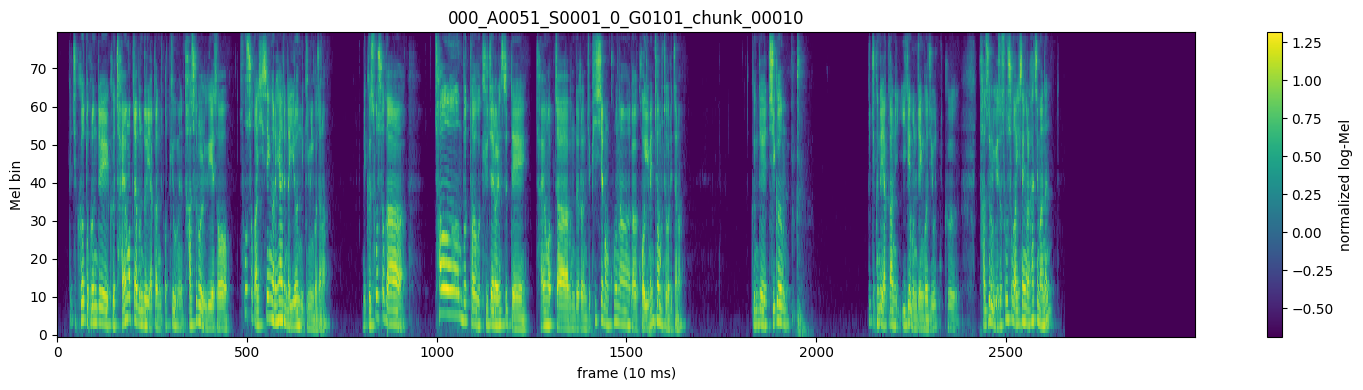

In [17]:
import matplotlib.pyplot as plt

first_record = records[10]
first_feature = np.load(OUTPUT_DIR / first_record['feature_path'], allow_pickle=False)

print('shape:', first_feature.shape)
print('dtype:', first_feature.dtype)
print('min/max:', float(first_feature.min()), float(first_feature.max()))
print('text:', first_record['text'])

plt.figure(figsize=(15, 4))
plt.imshow(first_feature, origin='lower', aspect='auto', interpolation='nearest')
plt.colorbar(label='normalized log-Mel')
plt.xlabel('frame (10 ms)')
plt.ylabel('Mel bin')
plt.title(first_record['id'])
plt.tight_layout()
plt.show()


## 8. Fine-tuning에서 읽는 예

```python
record = json.loads(manifest_line)
input_features = np.load(OUTPUT_DIR / record['feature_path'])
text = record['text']
label_token_ids = record['label_token_ids']
```

Hugging Face `WhisperProcessor`로 학습할 경우에는 `TOKENIZE_LABELS=False`로 두고 `record['text']`를 학습 Dataset 단계에서 해당 checkpoint의 tokenizer로 변환하는 방식을 권장합니다. 이미 저장된 Log-Mel 특징을 Processor의 feature extractor에 다시 넣으면 이중 전처리가 되므로 주의하세요.
